Customer Churn Prediction (Bank Customers)

Objective
  The goal of this project is to identify customers who are likely to leave the bank.

Problem Statement
  Banks want to retain customers. Predicting churn helps businesses take actions to keep customers.


Step 1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set(style="whitegrid")

# pandas → data handling
# numpy → numerical operations
# matplotlib & seaborn → visualization
# sklearn → machine learning

Step 2. Load Dataset

In [ ]:
df = pd.read_csv(r"G:\Data Science\DS 27\Data\Churn_Modelling1.csv")  # update file name if needed
df.head()

# read_csv() → loads dataset
# head() → shows first 5 rows

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:997)>

Step 3. Explore Data

In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns)
df.info()
df.describe()

# shape → number of rows & columns
# info() → data types + missing values
# describe() → summary statistics

Shape: (10000, 11)
Columns: Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   CreditScore      10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 859.5 KB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.999600,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.019997,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.000000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.000000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


Step 4. Check Missing Values

In [ ]:
print(df.isnull().sum())

# isnull().sum() → checks missing values

RowNumber          0
CustomerId         0
CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Step 5. Data Visualization

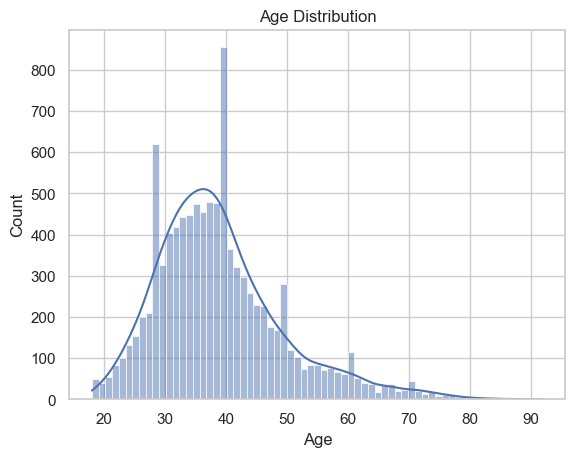

In [ ]:
# Age distribution
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# shows how age values are distributed

In [ ]:
# Geography vs Churn
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title("Geography vs Churn")
plt.show()

# countplot → compares categories
# hue=Exited → shows churn vs non-churn

ValueError: Could not interpret value `Geography` for `x`. An entry with this name does not appear in `data`.

In [ ]:
# Gender vs Churn
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Gender vs Churn")
plt.show()

Step 6. Data Preprocessing (Encoding)

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# converts text columns into numbers

Step 7. Features & Target

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

# X → input features
# y → target (churn or not)

Step 8. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# splits data into training and testing sets

Step 9. Train Model (Decision Tree)

In [ ]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Decision Tree model
# fit() → training
# predict() → prediction

Step 10. Model Evaluation

In [ ]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# accuracy → correct predictions %

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# confusion matrix → detailed performance

In [ ]:
# Visualize Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# heatmap → visual confusion matrix

Step 11. Feature Importance

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

# shows which features affect churn most

Step 12. Insights (Markdown Cell)

Insights
  - Customer churn is influenced by factors like age, geography, and gender.
  - Some regions have higher churn rates.
  - Feature importance shows which variables impact churn the most.
  - Decision Tree model helps identify patterns in customer behavior.

Conclusion
  Predicting customer churn helps businesses take action to retain customers and improve services.